## Task 1 — Dataset Acquisition and Initial Inspection

Purpose:
The goal of this notebook is to acquire the MNIST dataset and perform initial inspection to ensure the data is correctly loaded and suitable for statistical analysis.

Steps performed in this notebook:

- Load the MNIST dataset from OpenML
- Verify dataset dimensions and structure
- Inspect data types and pixel value ranges
- Visualize sample handwritten digits
- Examine the distribution of digit classes
- Save dataset files for downstream analysis

Outputs generated:

data/raw/X.npy
data/raw/y.npy
images/sample_digits.png
images/class_distribution.png

These outputs will be used in later tasks for statistical analysis and model training.

# Task 1: Dataset Acquisition and Initial Inspection

This notebook loads the MNIST dataset, validates its structure, inspects values, and generates initial visualizations for downstream statistical learning tasks.

## Dataset Loading

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

# Improve plot readability in notebooks
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "raw"
IMAGE_DIR = PROJECT_ROOT / "images"

DATA_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Load MNIST from OpenML
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data
y = mnist.target.astype(int)

print('MNIST loaded successfully.')

MNIST loaded successfully.


## Dataset Verification

In [4]:
n_samples, n_features = X.shape
n_classes = len(np.unique(y))

print(f'Number of samples: {n_samples}')
print(f'Number of features: {n_features}')
print(f'Number of classes: {n_classes}')

Number of samples: 70000
Number of features: 784
Number of classes: 10


In [5]:
import pandas as pd

summary_df = pd.DataFrame(
    {
        "Metric": [
            "Number of Samples",
            "Number of Features",
            "Number of Classes",
            "Minimum Pixel Value",
            "Maximum Pixel Value",
        ],
        "Value": [
            X.shape[0],
            X.shape[1],
            len(np.unique(y)),
            X.min(),
            X.max(),
        ],
    }
)

summary_df

,Metric,Value
0,Number of Samples,70000
1,Number of Features,784
2,Number of Classes,10
3,Minimum Pixel Value,0
4,Maximum Pixel Value,255


## Data Inspection

In [6]:
print(f'Feature dtype: {X.dtype}')
print(f'Label dtype: {y.dtype}')
print(f'Minimum pixel value: {np.min(X)}')
print(f'Maximum pixel value: {np.max(X)}')
print(f'Unique label values: {np.unique(y)}')

Feature dtype: int64
Label dtype: int64
Minimum pixel value: 0
Maximum pixel value: 255
Unique label values: [0 1 2 3 4 5 6 7 8 9]


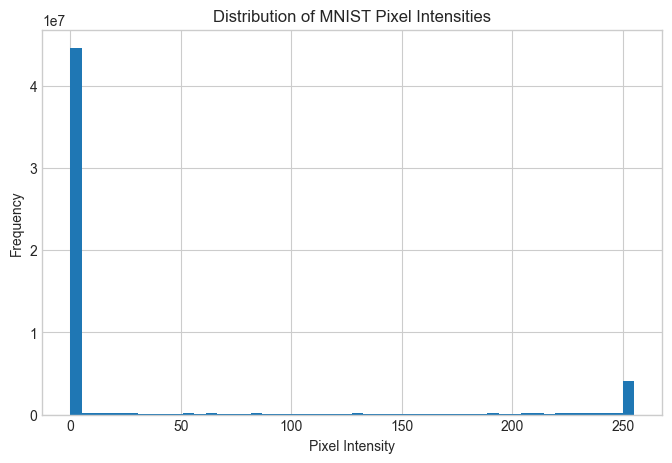

In [7]:
flatten_pixels = X.flatten()

plt.figure(figsize=(8, 5))
plt.hist(flatten_pixels, bins=50)
plt.title("Distribution of MNIST Pixel Intensities")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

In [8]:
# Convert to compact numeric arrays for storage and downstream processing
X_to_save = X.astype(np.uint8)
y_to_save = y.astype(np.uint8)

np.save(DATA_DIR / "X.npy", X)
np.save(DATA_DIR / "y.npy", y)

print('Saved: data/raw/X.npy')
print('Saved: data/raw/y.npy')

Saved: data/raw/X.npy
Saved: data/raw/y.npy


## Sample Visualization

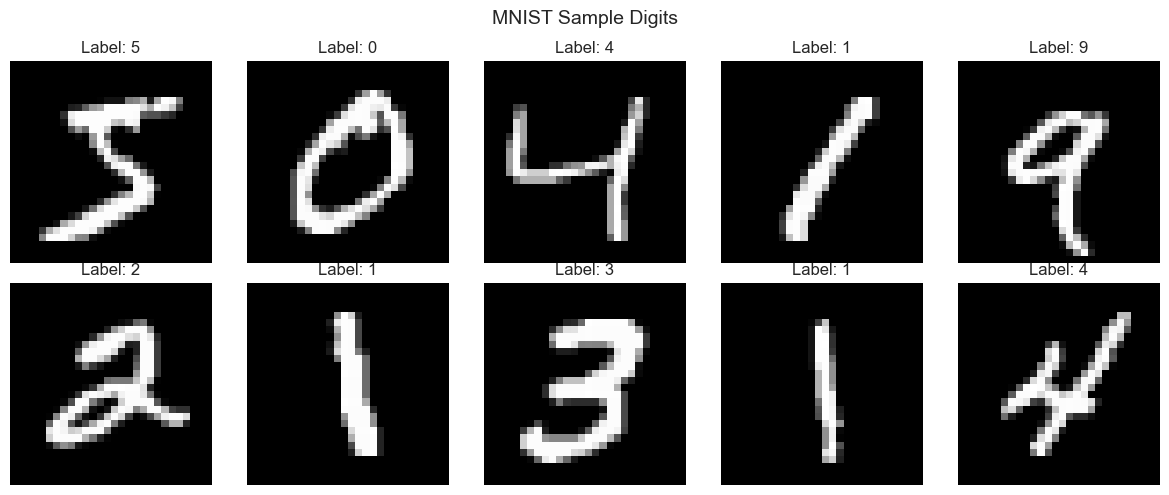

Saved: images/sample_digits.png


In [9]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.ravel()):
    image = X[i].reshape(28, 28)
    ax.imshow(image, cmap='gray')
    ax.set_title(f'Label: {y[i]}')
    ax.axis('off')

fig.suptitle('MNIST Sample Digits', fontsize=14)
fig.tight_layout()
fig.savefig(IMAGE_DIR / "sample_digits.png", dpi=150, bbox_inches="tight")
plt.show()

print('Saved: images/sample_digits.png')

## Class Distribution Analysis

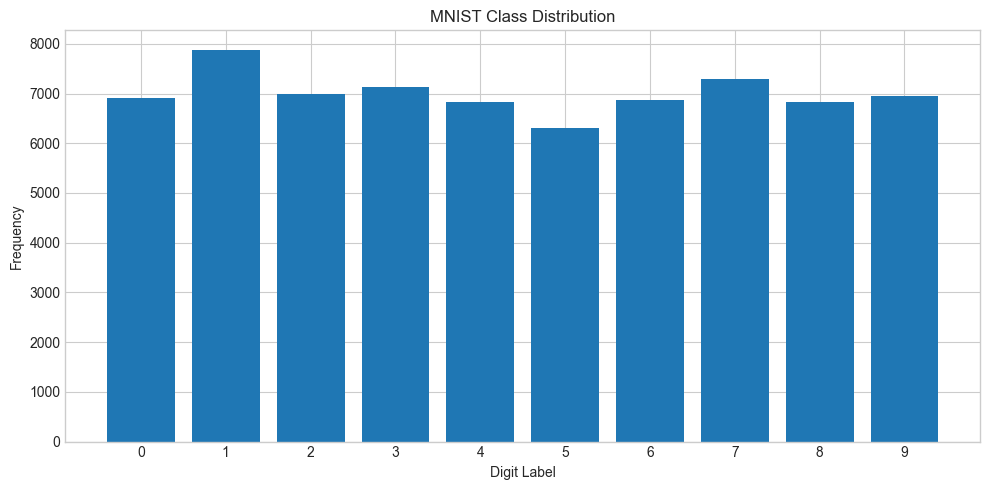

0    6903
1    7877
2    6990
3    7141
4    6824
5    6313
6    6876
7    7293
8    6825
9    6958
Name: count, dtype: int64
Saved: images/class_distribution.png


In [10]:
class_counts = pd.Series(y.astype(int)).value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(class_counts.index, class_counts.values)
plt.title('MNIST Class Distribution')
plt.xlabel('Digit Label')
plt.ylabel('Frequency')
plt.xticks(range(10))
plt.tight_layout()
plt.savefig(IMAGE_DIR / "class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(class_counts)
print('Saved: images/class_distribution.png')

In [11]:
from pathlib import Path
import numpy as np

project_root = Path.cwd().parent
x_path = project_root / "data" / "raw" / "X.npy"
y_path = project_root / "data" / "raw" / "y.npy"
sample_img_path = project_root / "images" / "sample_digits.png"
class_dist_path = project_root / "images" / "class_distribution.png"

print("## Task 1 Validation")
print()

print(f"X.npy found {'[OK]' if x_path.exists() else '[MISSING]'}")
print(f"y.npy found {'[OK]' if y_path.exists() else '[MISSING]'}")
print(f"sample_digits.png found {'[OK]' if sample_img_path.exists() else '[MISSING]'}")
print(f"class_distribution.png found {'[OK]' if class_dist_path.exists() else '[MISSING]'}")
print()

if x_path.exists() and y_path.exists():
    X_loaded = np.load(x_path)
    y_loaded = np.load(y_path)

    print("Loaded dataset shape:")
    print(f"X shape: {X_loaded.shape}")
    print(f"y shape: {y_loaded.shape}")
    print()

    if X_loaded.ndim == 2 and X_loaded.shape[1] == 784 and y_loaded.ndim == 1:
        print("Dataset ready for Task 2.")
    else:
        print("Dataset saved, but shapes are not in the expected MNIST format.")
else:
    print("Cannot load arrays because one or more required .npy files are missing.")

## Task 1 Validation

X.npy found [OK]
y.npy found [OK]
sample_digits.png found [OK]
class_distribution.png found [OK]

Loaded dataset shape:
X shape: (70000, 784)
y shape: (70000,)

Dataset ready for Task 2.


# Task 2 — Data Preprocessing and Preparation

Purpose:
Prepare the MNIST dataset for statistical analysis and machine learning by normalizing pixel values, verifying labels, and splitting the dataset into training and testing sets.

In [12]:
# Load dataset saved by Task 1
X = np.load(DATA_DIR / "X.npy")
y = np.load(DATA_DIR / "y.npy")

print("Dataset loaded")
print("X shape:", X.shape)
print("y shape:", y.shape)

Dataset loaded
X shape: (70000, 784)
y shape: (70000,)


In [13]:
# Normalize pixel values (scale from 0–255 to 0–1)

X_normalized = X / 255.0

print("Normalization completed")

print("Minimum pixel value:", X_normalized.min())
print("Maximum pixel value:", X_normalized.max())

Normalization completed
Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [14]:
# Verify label format

print("Label data type:", y.dtype)
print("Unique labels:", np.unique(y))
print("Number of classes:", len(np.unique(y)))

Label data type: int64
Unique labels: [0 1 2 3 4 5 6 7 8 9]
Number of classes: 10


In [15]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Dataset successfully split.")

Dataset successfully split.


In [16]:
print("Training images shape:", X_train.shape)
print("Testing images shape:", X_test.shape)

print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

Training images shape: (56000, 784)
Testing images shape: (14000, 784)
Training labels shape: (56000,)
Testing labels shape: (14000,)


In [17]:
# Check statistics of processed dataset

print("Processed Dataset Statistics")

print("Mean pixel value:", X_train.mean())
print("Standard deviation:", X_train.std())
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Processed Dataset Statistics
Mean pixel value: 0.1311067069685018
Standard deviation: 0.3086467631495595
Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [18]:
# Save processed datasets for later tasks

processed_dir = PROJECT_ROOT / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

np.save(processed_dir / "X_train.npy", X_train)
np.save(processed_dir / "X_test.npy", X_test)
np.save(processed_dir / "y_train.npy", y_train)
np.save(processed_dir / "y_test.npy", y_test)

print("Processed datasets saved successfully.")

Processed datasets saved successfully.
